This file can be used to compute W2 (MW11) = FvoigtHCD (Tan25) following two methods.

We will use MW21 cosmology and redshift

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from picca import constants
import h5py
from scipy import constants as scipy_constants

import sys
import os
sys.path.append(os.path.abspath(".."))
from w1_w2 import wave_to_fft_profile, resample_to_logk

In [2]:
# MW21 cosmology values
hubble, z = 0.71, 2.5
omegab, omegam = 0.046, 0.27
omegal = 1 - omegam
ns = 0.96

# Option A: f(Nhi, X) 

This will correspond to the left plot in Fig.3 on the overleaf draft (after some rescaling). With this function W2 is calculated following MW11 procedure: Eq.B3 in MW11 or Eq.B4 in overleaf draft

## MW11 

In [3]:
def f_Nhi(colden, k, b):
    y = k*(colden**b)
    return y

The parameters b1 and b2 are given in the paper. k1 and k2 are determinated so that:
- the integration of f_nhi from logNhi=19 to logNhi=20.3 (cm^-2) is 0.1
- f_Nhi(k1, b1) = f_Nhi(k2, b2) at logNhi = 20.3

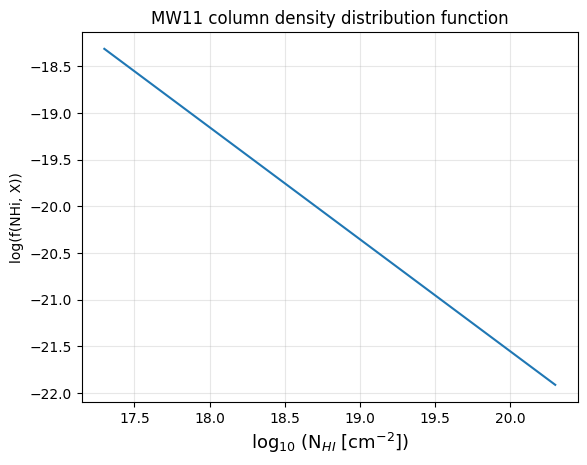

In [4]:
k1, b1 = 280.14, -1.2
k2, b2 = 4.24e14, -1.8

NHirange = np.linspace(17.3, 20.3)
colden1, colden2 = NHirange[NHirange < 20.3], NHirange[NHirange >= 20.3]
fnhi_mw11 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

plt.plot(NHirange, np.log10(fnhi_mw11))
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel('log(f(NHi, X))')
plt.title('MW11 column density distribution function')
plt.grid(alpha=0.3);

## Pyigm

In [5]:
data = '/Users/lflores/Documents/Research/phd/hcd/data/fNHi/fn_pyigm1'

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    print('----------------') 
    print('Data:')
    print(f.keys())

    fnhi_pyigm = 10**(f['fn'][:])

Atributes:
Redshift = 2.5
logNHI_max = 20.3
logNHI_min = 17.3
----------------
Data:
<KeysViewHDF5 ['fn', 'logNhi']>


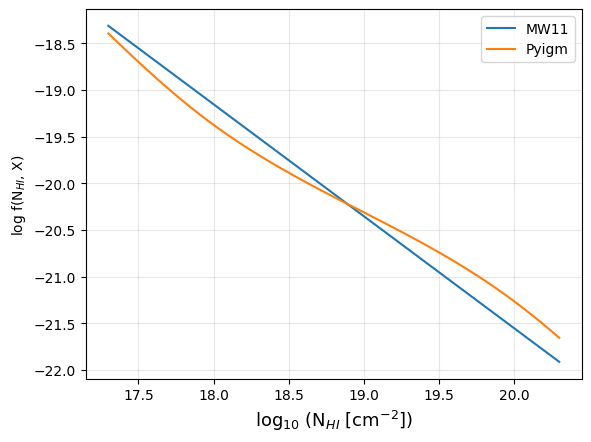

In [6]:
plt.plot(NHirange, np.log10(fnhi_mw11), label='MW11')
plt.plot(NHirange, np.log10(fnhi_pyigm), label='Pyigm')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'log f(N$_{HI}$, X)')
plt.grid(alpha=0.3)
plt.legend();

## Astrid

In [8]:
data_on = '/Users/lflores/Documents/Research/phd/hcd/data/ASTRID/spectra_ASTRID_z2.5_500x500x2500.hdf5'  # With self-shielding

with h5py.File(data_on, 'r') as f:
    print('Keys:', f.keys())
    header_on = f['Header']
    print('------ Header ------')
    for attr in header_on.attrs:
            print(f"{attr} : {header_on.attrs[attr]}")
    print('------ Data ------')
    colden = f['colden/H/1'][:]
    print('colden shape:', colden.shape)  

Keys: <KeysViewHDF5 ['Header', 'colden', 'spectra', 'tau']>
------ Header ------
Hz : 252.87249366801257
box : 250000.0
discarded : 0
hubble : 0.6774
nbins : 2500
npart : [165988309584 166375000000            0            0  10297622146
     11325619]
omegab : 0.0486
omegal : 0.6911
omegam : 0.3089
redshift : 2.499999947500001
------ Data ------
colden shape: (250000, 2500)


In [9]:
print('----- Useful information -----')
Lbox = 250  # Mpc/h
print('box size:', Lbox, 'Mpc/h')

# Number of skewers per side
Nsk = int(np.sqrt(colden.shape[0]))  # colden.on_shape[0] gives the size of the axis
print(Nsk,'skewers per side')

# Number of pixels per skewer
Np = colden.shape[1] # colden.on_shape[1] gives the size of the columns
print(Np, 'pixels per skewer')

# Pixel width 
Pw = Lbox/Np  # Mpc/h 
print(Pw, 'Mpc/h pixel width')
# We are dividing the total box width in comoving units by the number of pixels in each skewer

# Minimum separation between skewers
Ssk = Lbox/Nsk  # Mpc/h 
print(Ssk, 'Mpc/h skewer separation')
# We are dividing the total box width in comoving units by the number of skewers per side

----- Useful information -----
box size: 250 Mpc/h
500 skewers per side
2500 pixels per skewer
0.1 Mpc/h pixel width
0.5 Mpc/h skewer separation


In [17]:
log_edges = np.linspace(17.3, 20.3, 41)
bin_edges = 10**log_edges   # convert to linear for the histogram
counts, _ = np.histogram(colden, bins=bin_edges)

dlogN = log_edges[1] - log_edges[0]
xx = log_edges[:-1] + dlogN/2
Nmid = 10**xx
dN = np.log(10) * Nmid * dlogN
c_kms = scipy_constants.speed_of_light*1e-3
X_i = Lbox*100*hubble*((1+z)**2)/c_kms  # Absorption path lenght per los
Xtot = Nsk*Nsk*X_i # Total absorption path length of the simulation

fnhi_astrid = np.interp(NHirange, xx, counts/(Xtot*dN))

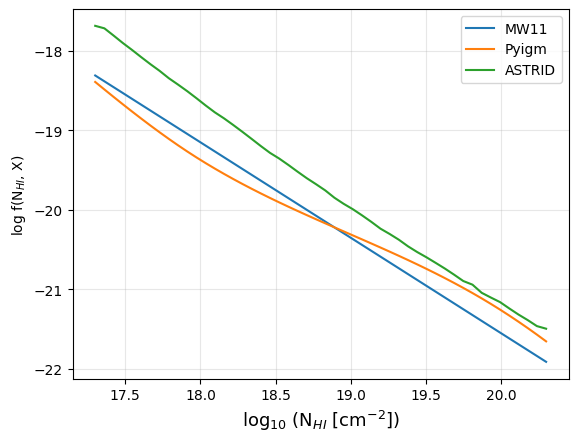

In [18]:

plt.plot(NHirange, np.log10(fnhi_mw11), label='MW11')
plt.plot(NHirange, np.log10(fnhi_pyigm), label='Pyigm')
plt.plot(NHirange, np.log10(fnhi_astrid), label='ASTRID')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'log f(N$_{HI}$, X)')
plt.grid(alpha=0.3)
plt.legend();

This function is equivalent to d^2N/dXdNhi, where X is the absorption path length. However, to implement the MW11 calculation of w1 and w2 we need to change from abrsorption path lenght to comoving distance. To do so, we can follow Eq. B14 on the overleaf

In [22]:
c_kms = constants.speed_light*1e-3  # kms^-1
conversion_factor = 100*hubble*((1+z)**2)/c_kms
cddf_mw11 = fnhi_mw11*conversion_factor
cddf_pyigm = fnhi_pyigm*conversion_factor
cddf_astrid = fnhi_astrid*conversion_factor

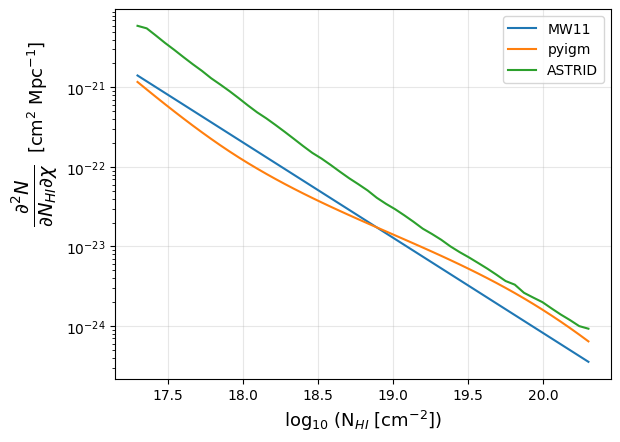

In [23]:
plt.plot(NHirange, cddf_mw11, label='MW11')
plt.plot(NHirange, cddf_pyigm, label='pyigm')
plt.plot(NHirange, cddf_astrid, label='ASTRID')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial^2 N}{\partial N_{HI}\partial \chi}$', fontsize=20)
plt.text(-0.18, 0.63, r'[cm$^2$ Mpc$^{-1}$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend();

This is Fig.3 (left) on the overleaf draft

## w2

With this cddf, W2 is calculated following MW11 procedure: Eq.B3 in MW11 or Eq.B4 in overleaf draft

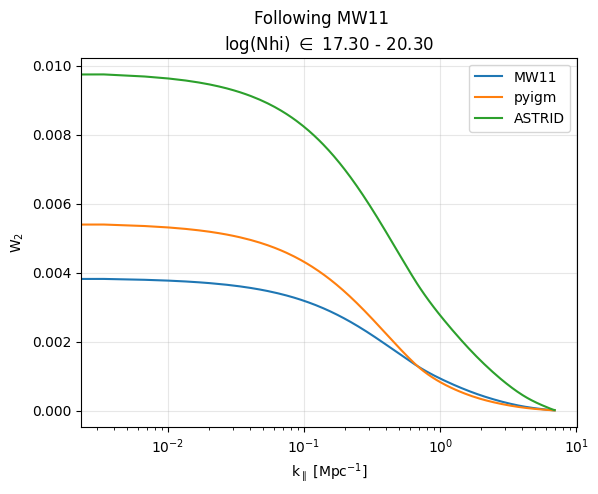

In [25]:
wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log
Fmean_hcd = 0.9779275149014024

# MW11
w2_int_MW11, w1_int_MW11 = [], []
w2_int_pyigm, w1_int_pyigm = [], []
w2_int_astrid, w1_int_astrid = [], []
for i, nhi_value in enumerate(NHirange):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)  # k is in h/Mpc and d in Mpc/h
    k_w1w2 /= hubble
    d *= hubble
    # MW11
    w2_int_MW11.append(cddf_mw11[i]*d*np.log(10)*(10**nhi_value))
    w1_int_MW11.append(cddf_mw11[i]*(d**2)*np.log(10)*(10**nhi_value))  # We will need this for later
    # pyigm
    w2_int_pyigm.append(cddf_pyigm[i]*d*np.log(10)*(10**nhi_value))
    w1_int_pyigm.append(cddf_pyigm[i]*(d**2)*np.log(10)*(10**nhi_value))  # We will need this for later
    # Astrid
    w2_int_astrid.append(cddf_astrid[i]*d*np.log(10)*(10**nhi_value))
    w1_int_astrid.append(cddf_astrid[i]*(d**2)*np.log(10)*(10**nhi_value))  # We will need this for later

# MW11
w2_int, w1_int = np.array(w2_int_MW11), np.array(w1_int_MW11)
w1_MW11 = np.trapezoid(w1_int, NHirange, axis=0)/Fmean_hcd  # Correction suggested in Tan25
w2_MW11 = np.trapezoid(w2_int, NHirange, axis=0)/Fmean_hcd  # Correction suggested in Tan25
# pyigm
w2_int, w1_int = np.array(w2_int_pyigm), np.array(w1_int_pyigm)
w1_pyigm = np.trapezoid(w1_int, NHirange, axis=0)/Fmean_hcd  # Correction suggested in Tan25
w2_pyigm = np.trapezoid(w2_int, NHirange, axis=0)/Fmean_hcd  # Correction suggested in Tan25
# Astrid
w2_int, w1_int = np.array(w2_int_astrid), np.array(w1_int_astrid)
w1_astrid = np.trapezoid(w1_int, NHirange, axis=0)/Fmean_hcd  # Correction suggested in Tan25
w2_astrid = np.trapezoid(w2_int, NHirange, axis=0)/Fmean_hcd  # Correction suggested in Tan25


plt.plot(k_w1w2, w2_MW11, label='MW11')
plt.plot(k_w1w2, w2_pyigm, label='pyigm')
plt.plot(k_w1w2, w2_astrid, label='ASTRID')
plt.ylabel(r'W$_2$')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))
plt.suptitle('Following MW11');

# Option B: f(n)

This function f(n) is the one used in Tan25: dN/dlog(Nhi)

## Pyigm

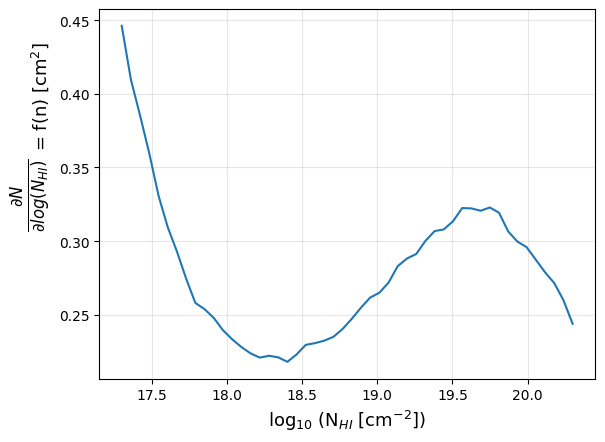

In [15]:
data = np.loadtxt('/Users/lflores/Documents/Research/phd/hcd/work_in_progress/Comparisons/fn_nomasking.txt')  # Obtained from '/global/cfs/projectdirs/desi/users/acuceu/notebooks_perl/pyigm/hcds/'
integral = np.trapezoid(data[0], data[1])
data[0] /= integral  # I was expecting integral = 1, but is somehow different. Tan specified that f(n) has to be area-normalized, so that is why I'm diving
fn_pyigm = np.interp(NHirange, data[1], data[0])  

plt.plot(NHirange, fn_pyigm)
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial N}{\partial log(N_{HI})}$', fontsize=17)
plt.text(-0.14, 0.63, r'= f(n) [cm$^2$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.grid(alpha=0.3)

## Astrid

In [16]:
colden_log = np.log10(colden)
counts, _ = np.histogram(colden_log, bins=NHirange)
mid_nhi = (NHirange[:-1] + (NHirange[1] - NHirange[0])/2)

/var/folders/4r/vx1gr4gd4p99y59swb8x2lzr0000gn/T/ipykernel_3293/2581987579.py:1: RuntimeWarning: divide by zero encountered in log10
  colden_log = np.log10(colden)


In [17]:
fn_astrid = np.interp(NHirange, mid_nhi, counts)
fn_astrid /= np.trapezoid(fn_astrid, NHirange)

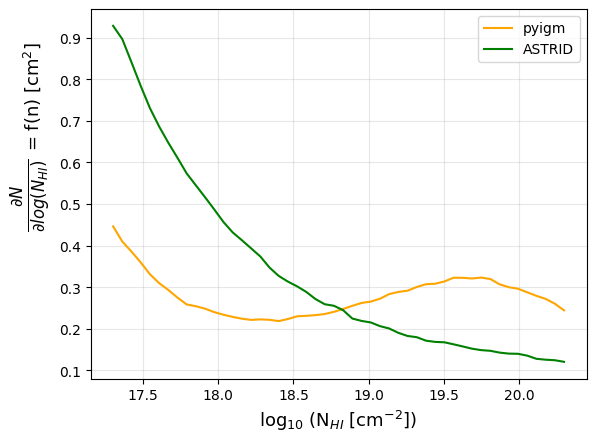

In [18]:
plt.plot(NHirange, fn_pyigm, color='orange', label='pyigm')
plt.plot(NHirange, fn_astrid, color='green', label='ASTRID')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial N}{\partial log(N_{HI})}$', fontsize=17)
plt.text(-0.14, 0.63, r'= f(n) [cm$^2$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.grid(alpha=0.3)
plt.legend();

## w2

And now we can calculate w2 following Tan25 method (Eq.3.3 and Eq.B22 on the overleaf draft)

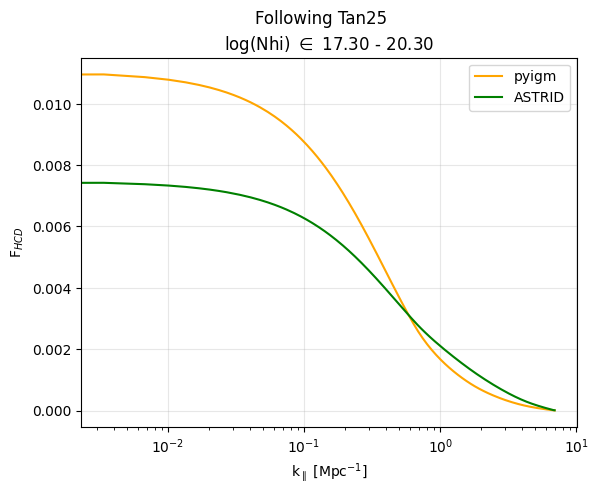

In [19]:
wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log
rho_hcd = 0.0018/hubble  # Mpc^-1 for z = 2.5 (Fig.7 right in Tan25)

w2_int_pyigm, w2_int_astrid = [], []
for i, nhi_value in enumerate(NHirange):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam)
    k_w1w2 /= hubble
    d *= hubble
    w2_int_pyigm.append(fn_pyigm[i]*d)
    w2_int_astrid.append(fn_astrid[i]*d)

# pyigm
w2_int = np.array(w2_int_pyigm)
w2_pyigm2 = rho_hcd*np.trapezoid(w2_int, NHirange, axis=0)
# ASTRID
w2_int = np.array(w2_int_astrid)
w2_astrid2 = rho_hcd*np.trapezoid(w2_int, NHirange, axis=0)


plt.plot(k_w1w2, w2_pyigm2, color='orange', label='pyigm')
plt.plot(k_w1w2, w2_astrid2, color='green', label='ASTRID')
plt.ylabel(r'F$_{HCD}$')
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.legend()
plt.xscale('log')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))
plt.suptitle('Following Tan25');

We can get all the results together in the same plot (assuming Fvoigt = w2)

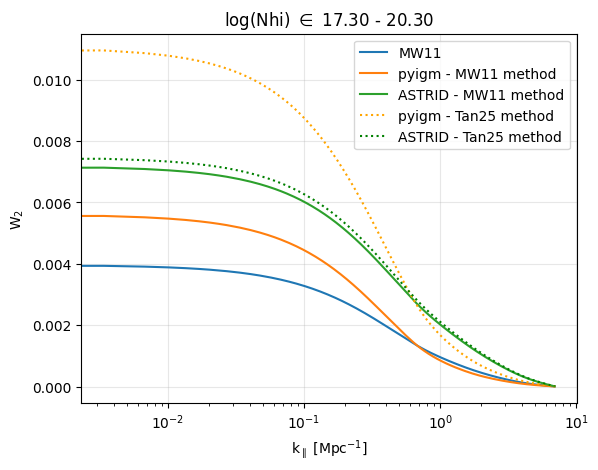

In [26]:
plt.plot(k_w1w2, w2_MW11, label='MW11')
plt.plot(k_w1w2, w2_pyigm, label='pyigm - MW11 method')
plt.plot(k_w1w2, w2_astrid, label='ASTRID - MW11 method')
plt.plot(k_w1w2, w2_pyigm2, color='orange', linestyle=':', label='pyigm - Tan25 method')
plt.plot(k_w1w2, w2_astrid2, color='green', linestyle=':', label='ASTRID - Tan25 method')
plt.ylabel(r'W$_2$')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));

This is Fig.4 on the overleaf draft

We can resample to logarithmic binning of k_paralel taking into account Nyquist frequency

In [25]:
print(r'Min value of k_los is', k_w1w2.min(), 'h/Mpc')
print(r'Max value of k_los is', k_w1w2.max(), 'h/Mpc')
print(r'But Nyquist frecuency is', np.pi/(Deltax), 'h/Mpc')
k_los, w2_MW11 = resample_to_logk(k_w1w2, w2_MW11, k_max=np.pi/(Deltax*2))  # Resample to logarithmic binning
k_los, w1_MW11 = resample_to_logk(k_w1w2, w1_MW11, k_max=np.pi/(Deltax*2))  
k_los, w2_vega = resample_to_logk(k_w1w2, w2_vega, k_max=np.pi/(Deltax*2))
k_los, w2_astrid = resample_to_logk(k_w1w2, w2_astrid, k_max=np.pi/(Deltax*2))
print('After truncation to avoid Nyquist frecuency')
print(r'Min value of k_los is', k_los.min(), 'Mpc^-1')
print(r'Max value of k_los is', k_los.max(), 'Mpc^-1')

Min value of k_los is 0.0 h/Mpc
Max value of k_los is 6.918327939869116 h/Mpc
But Nyquist frecuency is 4.912012837307073 h/Mpc
After truncation to avoid Nyquist frecuency
Min value of k_los is 0.003378089814389217 Mpc^-1
Max value of k_los is 2.4560064186535366 Mpc^-1


In [26]:
# LEt's export this into a txt file:
data = np.column_stack((k_los, w2_vega, w2_astrid, w2_MW11, w1_MW11))
np.savetxt('w2_functions.txt', data, fmt='%.6e', header='k_los, Vega, Astrid (with Tan25 procedure, MW11, w2 from MW11')